# Classification Metrics
For the purposes of this notebook, we only use a single split instead of cross-validation.

In [3]:
import pandas as pd

blood_transfusion = pd.read_csv("../transfusion.csv")
data = blood_transfusion.drop(columns="Class")
target = blood_transfusion["Class"]

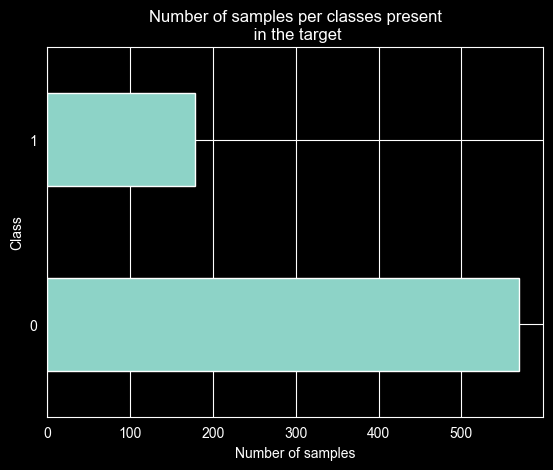

In [11]:
import matplotlib.pyplot as plt

target.value_counts().plot.barh()
plt.xlabel("Number of samples")
_ = plt.title("Number of samples per classes present\n in the target")

In [12]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0, test_size=0.5
)

In [13]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(data_train, target_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

We create a synthetic sample for a new potential donor. Our classifier predicts they will not donate blood again.

In [14]:
new_donor = pd.DataFrame(
    {
        "Recency": [6],
        "Frequency": [2],
        "Monetary": [1000],
        "Time": [20],
    }
)

In [15]:
classifier.predict(new_donor)

array([0])

## Accuracy as a Baseline
The accuracy is a baseline metric we use that calculates the mean percentage of correct predictions.

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(target_test, target_predicted)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.778


## Confusion Matrix and Derived Metrics
The accuracy we calculated did not take into account the type of error the classifier was making. The **confusion matrix** gives us more granular details to identify false-negatives and false-positives.

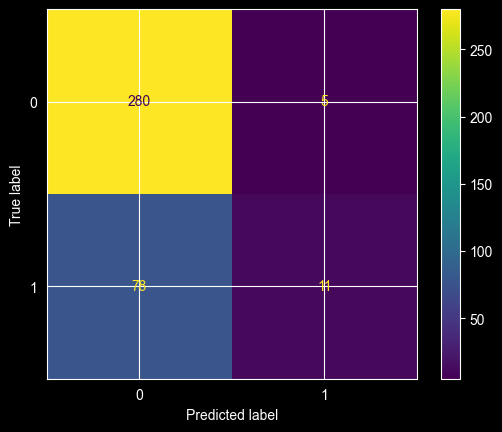

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

_ = ConfusionMatrixDisplay.from_estimator(classifier, data_test, target_test)

We have two key metrics that we can derive from this:
- **Precision Score**: `TP / (TP + FP)` or how likely the person actually gave blood when the classifier predicted they did
- **Recall Score**: `TP / (TP + FN)` or how well the classifier is able to predict people who did give blood

In [20]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(target_test, target_predicted, pos_label=1)
recall = recall_score(target_test, target_predicted, pos_label=1)

print(f"Precision score: {precision:.3f}")
print(f"Recall score: {recall:.3f}")

Precision score: 0.688
Recall score: 0.124


The classifier did have a fair precision, however, it misclassified a lot of people who gave blood as having not donating blood.

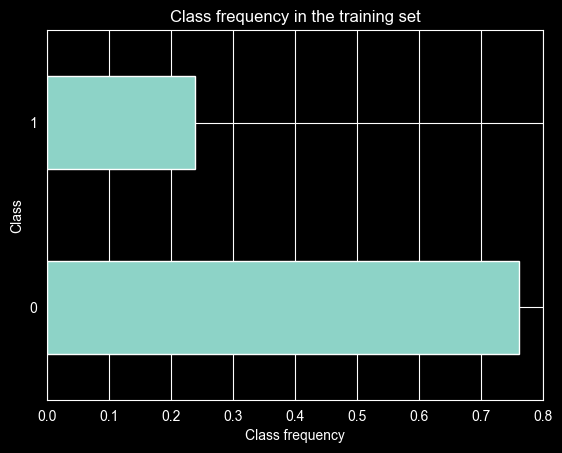

In [21]:
target_train.value_counts(normalize=True).plot.barh()
plt.xlabel("Class frequency")
_ = plt.title("Class frequency in the training set")

It can be seen that due to this class imbalance, it will naturally have a higher accuracy but a really low recall, as there are more samples in the negative class. A dummy classifier would achieve similar results if it scored on the most frequent class occurrence.

When classes are imbalanced, accuracy should not be used. Either precision or recall should be used, or the balanced accuracy should be used (which is the average recall obtained on each class).

In [27]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(data_train, target_train)
print(
    "Accuracy of the dummy classifier: "
    f"{dummy_classifier.score(data_test, target_test):.3f}"
)

Accuracy of the dummy classifier: 0.762


In [22]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy = balanced_accuracy_score(target_test, target_predicted)
print(f"Balanced accuracy: {balanced_accuracy:.3f}")

Balanced accuracy: 0.553


## Probability Thresholds
By default, the probability threshold to make a classification decision is 0.5. On the below precision-recall curve, each blue cross represents a level of probability which we used as a decision threshold. By varying this threshold, we get different precision vs. recall values.

A perfect classifier would have a precision of 1 for *all recall values*. The metric characterizing the curve is the **area under the curve (AUC)** and is named **average precision (AP)**. Thus, `AP = 1` for a perfect classifier.

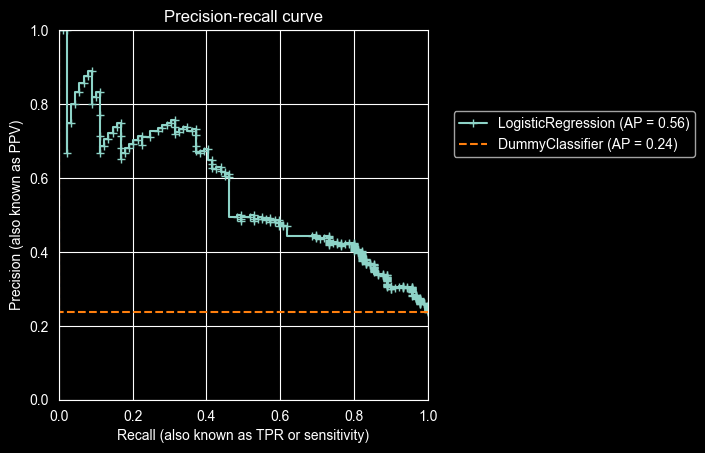

In [29]:
from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_estimator(
    classifier, data_test, target_test, pos_label=1, marker="+"
)
disp = PrecisionRecallDisplay.from_estimator(
    dummy_classifier,
    data_test,
    target_test,
    pos_label=1,
    color="tab:orange",
    linestyle="--",
    ax=disp.ax_,
)
plt.xlabel("Recall (also known as TPR or sensitivity)")
plt.ylabel("Precision (also known as PPV)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = disp.ax_.set_title("Precision-recall curve")

When we are interested on the negative class, we can use two other metrics:
- **Sensitivity**: the exact same as recall.
- **Specificity**: `TN / (TN + FP)` or the proportion of correctly classified samples in the negative class.

These can be plotted on the **Receiver Operating Characteristic (ROC) curve**:

/Users/michael/Development/Learning/scikit/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/michael/Development/Learning/scikit/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


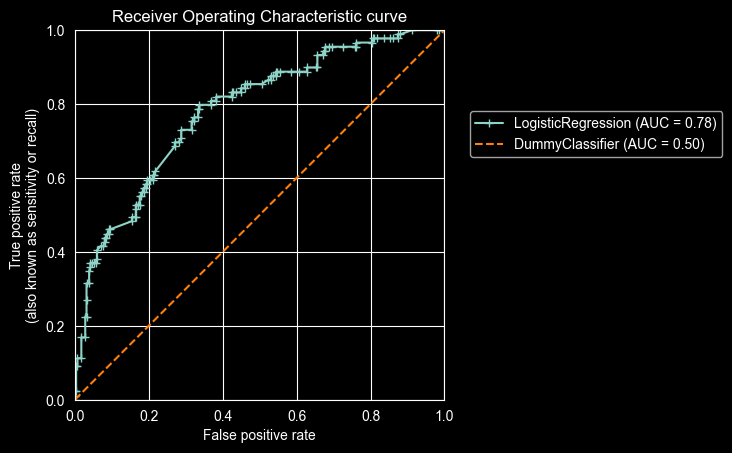

In [31]:
from sklearn.metrics import RocCurveDisplay

disp = RocCurveDisplay.from_estimator(
    classifier, data_test, target_test, pos_label=1, marker="+"
)
disp = RocCurveDisplay.from_estimator(
    dummy_classifier,
    data_test,
    target_test,
    pos_label=1,
    color="tab:orange",
    linestyle="--",
    ax=disp.ax_,
)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate\n(also known as sensitivity or recall)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = disp.ax_.set_title("Receiver Operating Characteristic curve")

/Users/michael/Development/Learning/scikit/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


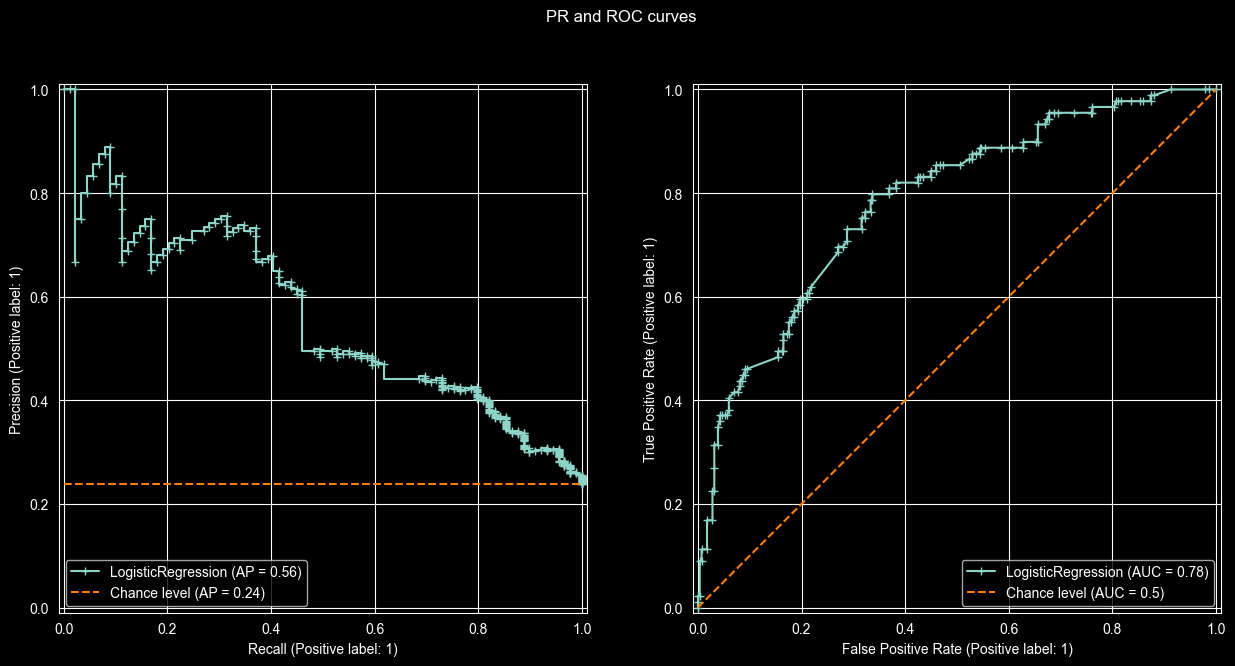

In [33]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 7))

PrecisionRecallDisplay.from_estimator(
    classifier,
    data_test,
    target_test,
    pos_label=1,
    marker="+",
    plot_chance_level=True,
    chance_level_kw={"color": "tab:orange", "linestyle": "--"},
    ax=axs[0],
)
RocCurveDisplay.from_estimator(
    classifier,
    data_test,
    target_test,
    pos_label=1,
    marker="+",
    plot_chance_level=True,
    chance_level_kw={"color": "tab:orange", "linestyle": "--"},
    ax=axs[1],
)

_ = fig.suptitle("PR and ROC curves")